****
IMPORT
****

In [1]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, classification_report
from sklearn.inspection import permutation_importance

c:\Users\Nérion\Documents\Code\5_OpenClassRooms\3_automatically_classify_information\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


****
TRAIN / TEST
****

In [2]:
# 1. Chargement du dataset de training choisi
df_ml = pd.read_parquet("../data/dataframe_training.parquet")

# 2. Séparation de la cible (y) et des caractéristiques (X)
# On supprime explicitement la cible et l'identifiant pour la matrice X
X = df_ml.drop(columns=['a_quitte_l_entreprise', 'id_user'], errors='ignore')
y = df_ml['a_quitte_l_entreprise']

# 3. Création des jeux d'apprentissage et de test (Stratified pour équilibrer le turnover)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"📦 Jeux d'apprentissage et de test créés avec succès !")
print(f"Train set (X_train) : {X_train.shape[0]} lignes | Test set (X_test) : {X_test.shape[0]} lignes")

📦 Jeux d'apprentissage et de test créés avec succès !
Train set (X_train) : 1176 lignes | Test set (X_test) : 294 lignes


****
Modèles
****

In [3]:
# 1. Modèle Baseline / Dummy (Prédit toujours la classe la plus fréquente)
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train, y_train)

# 2. Modèle Linéaire (Régression Logistique)
# max_iter augmenté pour garantir la convergence mathématique
model_linear = LogisticRegression(max_iter=1000, random_state=42)
model_linear.fit(X_train, y_train)

# 3. Modèle Non-Linéaire (Random Forest - Optimal pour le Label Encoding)
model_nonlinear = RandomForestClassifier(n_estimators=100, random_state=42)
model_nonlinear.fit(X_train, y_train)

print("🎯 Les 3 modèles ont été entraînés avec succès sur le jeu d'apprentissage !")

🎯 Les 3 modèles ont été entraînés avec succès sur le jeu d'apprentissage !


c:\Users\Nérion\Documents\Code\5_OpenClassRooms\3_automatically_classify_information\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


`DETAIL`
- Dummy => Établit la baseline la plus logique face à un dataset déséquilibré. Le modèle prédit aveuglément la situation majoritaire, ici l'employé qui reste.
- Linear (max_iter=1000) => Augmenté par rapport à la valeur par défaut (100) pour garantir la convergence mathématique de l'algorithme. Les données contenant plusieurs features créées et des échelles différentes, cela donne au solveur linéaire le temps de trouver la frontière de décision optimale sans planter.
- NonLinear (n_estimators=100) => Paramètre standard et robuste qui instancie un ensemble de 100 arbres de décision indépendants. Ce nombre offre un excellent compromis entre puissance prédictive et temps de calcul, tout en réduisant la variance globale par rapport à un arbre de décision unique.
- random_state=42 => Fixe la graine aléatoire pour garantir la reproductibilité stricte des résultats.

****
Métriques
****

In [4]:
# Fonction d'extraction automatique des métriques
def extraire_metriques(model, X, y, nom_jeu):
    y_pred = model.predict(X)
    return {
        f"Accuracy ({nom_jeu})": accuracy_score(y, y_pred),
        f"Precision ({nom_jeu})": precision_score(y, y_pred, zero_division=0),
        f"Recall ({nom_jeu})": recall_score(y, y_pred, zero_division=0),
        f"F1-Score ({nom_jeu})": f1_score(y, y_pred, zero_division=0)
    }

# Compilation des résultats pour chaque modèle
dict_resultats = {}

for nom, model in [("Modèle Dummy", model_dummy), ("Modèle Linéaire (LogReg)", model_linear), ("Modèle Non-Linéaire (RF)", model_nonlinear)]:
    # Métriques d'apprentissage
    metriques_train = extraire_metriques(model, X_train, y_train, "Train")
    # Métriques de validation (Test)
    metriques_test = extraire_metriques(model, X_test, y_test, "Test")
    
    # Fusion des dictionnaires pour ce modèle
    dict_resultats[nom] = {**metriques_train, **metriques_test}

# Conversion en DataFrame pour affichage propre sous forme de tableau
df_metriques = pd.DataFrame(dict_resultats).T

# Réorganisation esthétique des colonnes (Train à côté de Test)
colonnes_ordonnees = [
    "Accuracy (Train)", "Accuracy (Test)",
    "Precision (Train)", "Precision (Test)",
    "Recall (Train)", "Recall (Test)",
    "F1-Score (Train)", "F1-Score (Test)"
]

# Affichage du tableau final arrondi à 3 décimales
display(df_metriques[colonnes_ordonnees].round(3))

,Accuracy (Train),Accuracy (Test),Precision (Train),Precision (Test),Recall (Train),Recall (Test),F1-Score (Train),F1-Score (Test)
Modèle Dummy,0.838,0.840,0.000,0.000,0.000,0.000,0.000,0.000
Modèle Linéaire (LogReg),0.860,0.844,0.745,0.533,0.200,0.170,0.315,0.258
Modèle Non-Linéaire (RF),0.999,0.827,1.000,0.375,0.995,0.128,0.997,0.190


`OBSERVATION:`
- Dummy => Ce modèle "naïf" se contente de prédire la classe majoritaire (l'employé reste) car le dataset est déséquilibré. Il prouve que l'Accuracy est une métrique trompeuse ici : un modèle peut sembler performant tout en étant totalement incapable de détecter la moindre démission
- Linear => Sa précision indique qu'il est capable de prédir plus d'un départ sur 2. Moins sensible au surapprentissage que le Random Forest, il reste cependant limité par le déséquilibre des classes. Son Recall de 0.170 montre qu'il ne parvient pas à intercepter efficacement les signaux faibles de turnover.
- NonLinear => Des scores quasi-parfaits sur le jeu d'entraînement qui s'effondrent sur le jeu de test. C'est un cas d'overfitting.

``Ces résultats indique clairement que le dataset est trop déséquilibré et nécessite un rééquilibrage ou l'adaptation de paramètre des modèles.``

`Réflexion Méthodologique:`
- Faux Négatif (Le pire scénario) : Le modèle prédit que l'employé reste (0), mais il démissionne (1). L'entreprise subit un départ surprise, la perte d'un talent, et des coûts de recrutement imprévus.
- Faux Positif (Le scénario gérable) : Le modèle prédit que l'employé va partir (1), mais il reste (0). Les RH vont peut-être lui proposer un entretien, une petite augmentation ou une formation pour le retenir. C'est un coût de prévention, mais l'employé est toujours là.

- Conclusion : Il vaut mieux alerter à tort que de rater un départ. Il faudra donc prioriser la métrique Recall tout en garadant une bonne Précision.

****
Validation Croisée
****

In [5]:
# 1. Fonction d'évaluation en Cross-Validation
def evaluer_modele_cv(model, X_train, y_train, n_splits=5):
    """
    Évalue un modèle avec Stratified K-Fold et retourne les moyennes/écarts-types.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = ['recall', 'precision', 'f1']
    
    # Exécution de la validation croisée
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    
    # Affichage propre des résultats
    print(f"--- Résultats Validation Croisée ({n_splits} Folds) ---")
    
    # On regarde le train vs test pour vérifier l'Overfit
    print(f"F1-Score (Train) : {scores['train_f1'].mean():.3f} +/- {scores['train_f1'].std():.3f}")
    print(f"F1-Score (Test)  : {scores['test_f1'].mean():.3f} +/- {scores['test_f1'].std():.3f}")
    print("-" * 30)
    print(f"Recall (Test)    : {scores['test_recall'].mean():.3f} +/- {scores['test_recall'].std():.3f}")
    print(f"Precision (Test) : {scores['test_precision'].mean():.3f} +/- {scores['test_precision'].std():.3f}")
    
    return scores

****
Modèle Non-Linéaire équilibré
****

In [6]:
# 1. On définit le modèle de base (toujours équilibré)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. On définit la "grille" des paramètres à tester
# Le modèle va tester chaque max_depth combiné avec chaque min_samples_leaf
grille_parametres = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 5, 10],
    'n_estimators': [100]
}

# 3. Lancement du GridSearchCV (optimisé pour le F1-Score)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=grille_parametres,
    scoring='f1',       # On demande à la machine de maximiser le F1-Score
    cv=5,               # Validation croisée à 5 plis intégrée
    n_jobs=-1,          # Utilise tous les coeurs de ton processeur pour aller plus vite
    verbose=1
)

# Entraînement de la grille sur les données
grid_search.fit(X_train, y_train)

# 4. Affichage du grand gagnant !
print("🏆 Meilleurs hyperparamètres trouvés par la machine :")
print(grid_search.best_params_)

# Tu peux extraire le meilleur modèle directement pour la suite
meilleur_modele_rf = grid_search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
🏆 Meilleurs hyperparamètres trouvés par la machine :
{'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100}


In [7]:
# 1. Extraction directe du meilleur modèle entraîné par le GridSearch
rf_balanced_optimal = grid_search.best_estimator_

# 2. Lancement de ta validation croisée pour afficher les résultats
print("📊 Évaluation du Meilleur Random Forest (Trouvé par GridSearch) :")
resultats_cv = evaluer_modele_cv(rf_balanced_optimal, X_train, y_train)

# (Optionnel) Le modèle extrait est déjà entraîné, mais pour garantir 
# que ton pipeline soit clair, tu peux le ré-entraîner explicitement sur tout le Train :
rf_balanced_optimal.fit(X_train, y_train)

📊 Évaluation du Meilleur Random Forest (Trouvé par GridSearch) :
--- Résultats Validation Croisée (5 Folds) ---
F1-Score (Train) : 0.622 +/- 0.011
F1-Score (Test)  : 0.457 +/- 0.060
------------------------------
Recall (Test)    : 0.532 +/- 0.090
Precision (Test) : 0.405 +/- 0.057


RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, random_state=42)

`Observation:`
- On a une bonne augmentation du Recall comme voulu puique nous sommes passé de 12 à 53% sur le jeu de test tout en améliorant légèrement la précision. l'algorithme à donc bien cessé d'ignorer la classe minoritaire.
- Quand on regarde l'écart des F1-score être test et train on observe toujours overfitting.

****
Graphique
****

📊 Performances théoriques au point optimal (Point Rouge) :
 - Seuil optimal : 0.501
 - Recall        : 0.537
 - Precision     : 0.411


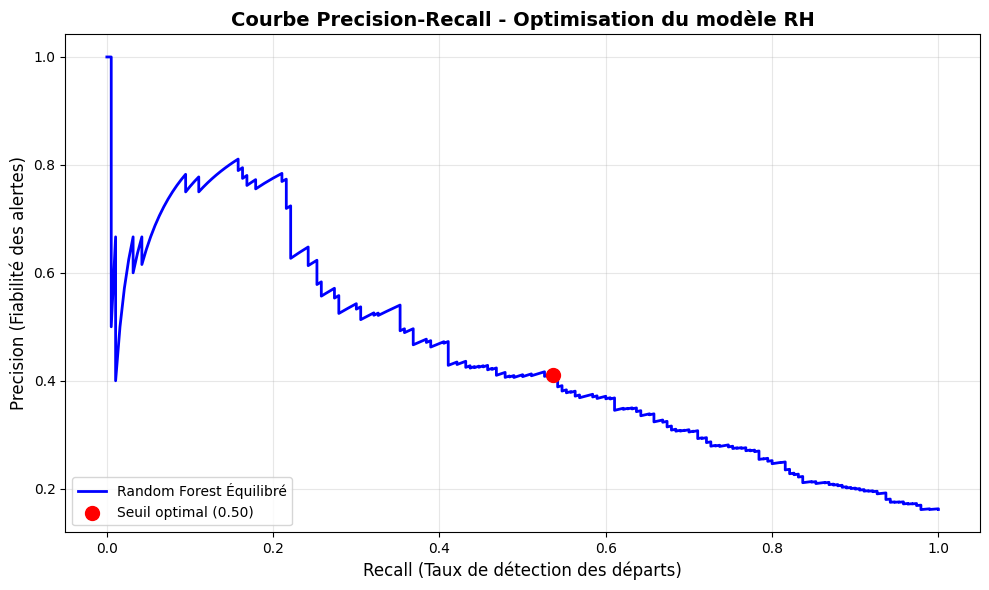

In [8]:
# 1. Calcul des probabilités de départ sur le jeu de test
y_probs_cv = cross_val_predict(rf_balanced_optimal, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# 2. Calcul des points de la courbe Precision-Recall
precisions_cv, recalls_cv, seuils_cv = precision_recall_curve(y_train, y_probs_cv)

# 3. Recherche du seuil qui maximise le F1-Score
# Attention : la liste 'seuils' a un élément de moins que precisions/recalls
f1_scores = 2 * (precisions_cv[:-1] * recalls_cv[:-1]) / (precisions_cv[:-1] + recalls_cv[:-1])
meilleur_index = np.argmax(f1_scores)
meilleur_seuil = seuils_cv[meilleur_index]

print("📊 Performances théoriques au point optimal (Point Rouge) :")
print(f" - Seuil optimal : {meilleur_seuil:.3f}")
print(f" - Recall        : {recalls_cv[meilleur_index]:.3f}")
print(f" - Precision     : {precisions_cv[meilleur_index]:.3f}")

# 4. Tracé du graphique
plt.figure(figsize=(10, 6))
plt.plot(recalls_cv, precisions_cv, label='Random Forest Équilibré', color='b', linewidth=2)
plt.scatter(recalls_cv[meilleur_index], precisions_cv[meilleur_index], color='red', s=100, zorder=5, 
            label=f'Seuil optimal ({meilleur_seuil:.2f})')

plt.title('Courbe Precision-Recall - Optimisation du modèle RH', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Taux de détection des départs)', fontsize=12)
plt.ylabel('Precision (Fiabilité des alertes)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

`Observation`
- Le seuil optimal est prohe du seuil par default de 0.5 et améliore légèrement les resultat recall comme précision.
- On peux aussi observé selon les objectifs quel y_pred définir selon les objectifs, es que l'on souhaite diminuer les faux positif ou negatif. Jouant ainsi sur le ratio précision/recall.

****
Métriques
****

In [9]:
# 1. Application du seuil sur les probabilités de la Validation Croisée
y_pred_cv_optimal = (y_probs_cv >= meilleur_seuil).astype(int)

# 2. Rapport de Classification (On compare avec y_train !)
print("📊 Rapport de Classification - Validation Croisée (Seuil Optimal) :")
print(classification_report(y_train, y_pred_cv_optimal, target_names=["Reste (0)", "Part (1)"]))

📊 Rapport de Classification - Validation Croisée (Seuil Optimal) :
              precision    recall  f1-score   support

   Reste (0)       0.91      0.85      0.88       986
    Part (1)       0.41      0.54      0.47       190

    accuracy                           0.80      1176
   macro avg       0.66      0.69      0.67      1176
weighted avg       0.83      0.80      0.81      1176



`Observation:`
- On obtiens bien les résultat attendu part le graphique de courbe precision-recall.

In [10]:
# 1. Le modèle calcule les probabilités sur le NOUVEAU jeu (Test)
y_probs_test = rf_balanced_optimal.predict_proba(X_test)[:, 1]

# 2. Application de ton seuil optimal trouvé précédemment
y_pred_test_optimal = (y_probs_test >= meilleur_seuil).astype(int)

# 3. Rapport de Classification Final (On compare avec y_test)
print("🏆 Rapport de Classification FINAL sur le Test (Seuil Optimal) :")
print(classification_report(y_test, y_pred_test_optimal, target_names=["Reste (0)", "Part (1)"]))

🏆 Rapport de Classification FINAL sur le Test (Seuil Optimal) :
              precision    recall  f1-score   support

   Reste (0)       0.89      0.82      0.85       247
    Part (1)       0.32      0.45      0.37        47

    accuracy                           0.76       294
   macro avg       0.60      0.63      0.61       294
weighted avg       0.80      0.76      0.77       294



`Observation:`
- On voit une regression par rapport a la moyenne des modèles croisé, une précision et recall significativement plus faible.
- Cette baisse s'explique par deux phénomènes :
- - Un léger surapprentissage (overfitting) : Le modèle a un peu trop mémorisé les spécificités de l'entraînement et perd en capacité de généralisation face à de nouveaux profils.
- - La taille de l'échantillon (Variance) : Le jeu de test contient très peu de vrais départs (47). Sur un volume aussi restreint, rater ne serait-ce que 3 ou 4 prédictions fait chuter les pourcentages de manière drastique.

`Conclusion:`
- Le modèle Random Forest classique à été poussé à ses limites mathématiques (optimisation des hyperparamètres + ajustement du seuil métier). Le léger décrochage sur le jeu de test montre que jongler avec le paramètre class_weight ne suffit plus à compenser le manque cruel de données de départs. Pour franchir un nouveau cap, il faut désormais créer de la donnée synthétique avec la technique du SMOTE (Oversampling)

****
Best Feature
****

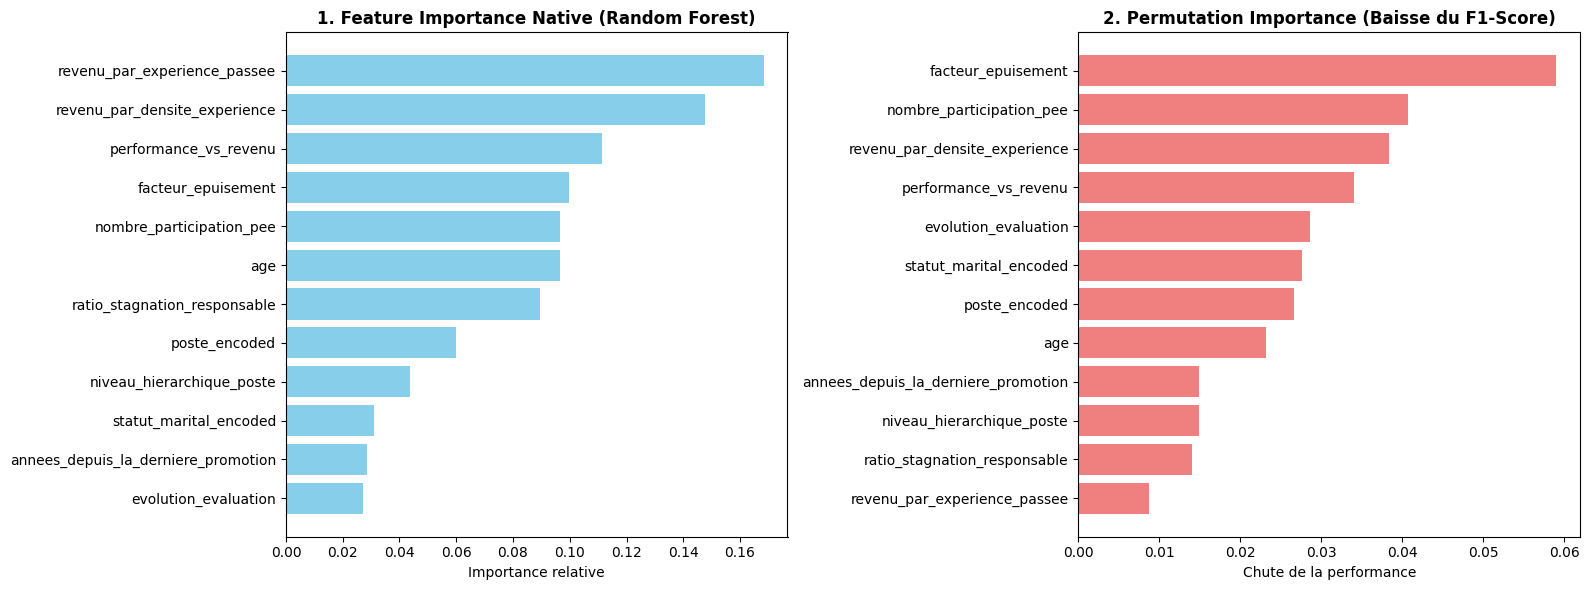

In [11]:
# 1. Feature Importance Native (Générée par le Random Forest lui-même)
importances_natives = rf_balanced_optimal.feature_importances_
noms_features = X_train.columns

# Création d'un DataFrame pour un affichage propre
df_importance_native = pd.DataFrame({
    'Feature': noms_features,
    'Importance': importances_natives
}).sort_values(by='Importance', ascending=True)

# 2. Permutation Importance (Évaluée sur le jeu de test)
# On mélange chaque colonne une par une et on regarde l'impact sur le F1-Score
resultats_permutation = permutation_importance(
    rf_balanced_optimal, X_test, y_test, scoring='f1', n_repeats=10, random_state=42
)

df_importance_perm = pd.DataFrame({
    'Feature': noms_features,
    'Importance': resultats_permutation.importances_mean
}).sort_values(by='Importance', ascending=True)

# 3. Affichage comparatif
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique Native
axes[0].barh(df_importance_native['Feature'], df_importance_native['Importance'], color='skyblue')
axes[0].set_title("1. Feature Importance Native (Random Forest)", fontweight='bold')
axes[0].set_xlabel("Importance relative")

# Graphique Permutation
axes[1].barh(df_importance_perm['Feature'], df_importance_perm['Importance'], color='lightcoral')
axes[1].set_title("2. Permutation Importance (Baisse du F1-Score)", fontweight='bold')
axes[1].set_xlabel("Chute de la performance")

plt.tight_layout()
plt.show()

`Observation:`
- On voit un fort contraste sur la première variable revenu_par_experience_passee qui a un fort poids dans le graphique de gauche mais à contrario dans le graphique de droit est presque inutile.
- Les feature native semble favoriser des varaibles financière créé tandis car les arbres décision favorise les donnée continu comme les ratios (cas de ces 3 feature) car elle offre une infinité de façon de coupé la donnée.
- Côté permutation on voit une plus grande importance dans les variable metier même si les variable financiere ne sont pas loin.
- Il y a donc un equilibre a trouver entre les variable metier et financière pour maximiser les resultats et trouve le plus de raison de départ.

****
SHAP Global
****

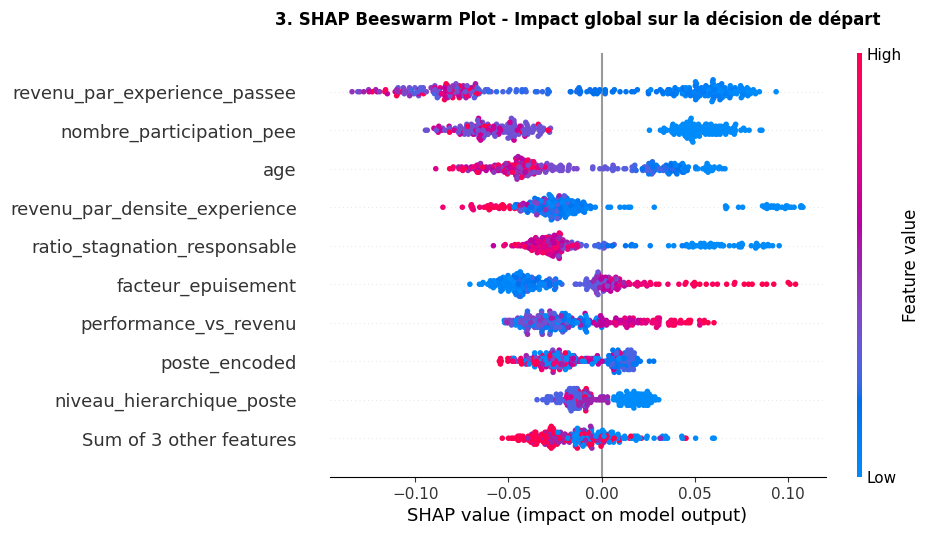

In [12]:
# Initialisation de l'explainer SHAP optimisé pour les arbres (TreeExplainer)
explainer = shap.TreeExplainer(rf_balanced_optimal)

# Calcul des valeurs SHAP sur le jeu de test
shap_values = explainer(X_test)

# Pour un Random Forest binaire, SHAP renvoie souvent les explications pour les 2 classes.
# Nous voulons expliquer la classe 1 (le DÉPART).
# Si shap_values est un tableau 3D, on extrait la classe 1 : [:, :, 1]
if len(shap_values.shape) == 3:
    shap_values_depart = shap_values[:, :, 1]
else:
    shap_values_depart = shap_values

# Affichage du Beeswarm Plot
plt.figure(figsize=(10, 6))
plt.title("3. SHAP Beeswarm Plot - Impact global sur la décision de départ\n", fontweight='bold')
shap.plots.beeswarm(shap_values_depart, max_display=10)

`Observation:`
- L'analyse combinée des trois variables principales met en évidence un profil type à fort risque de départ : les jeunes collaborateurs récemment embauchés. Ce constat est très cohérent d'un point de vue RH. En effet, un nouvel arrivant (qui n'a par exemple pas encore pu capitaliser sur le PEE de l'entreprise) n'a pas encore créé de lien d'attachement financier ou psychologique fort avec la structure, ce qui le rend beaucoup plus volatil face au marché de l'emploi.

****
Analyse des corrélations croisées
****

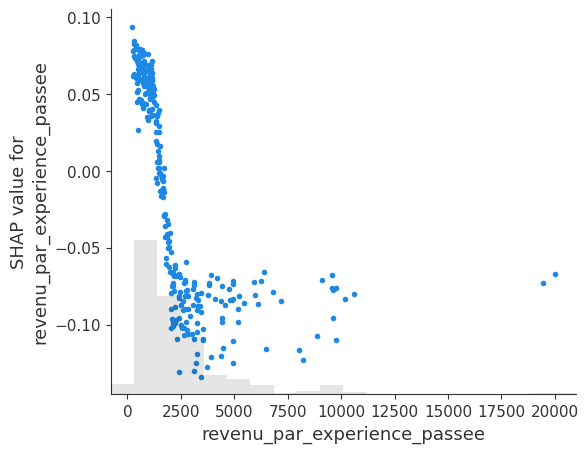

In [13]:
# Remplace par le nom exact de la feature la plus importante vue dans le Beeswarm
nom_feature_top1 = X_test.columns[1]

# Le Scatter Plot montre comment la valeur de la feature modifie la probabilité de départ
# SHAP coloriera automatiquement les points avec la variable avec laquelle elle interagit le plus
shap.plots.scatter(shap_values_depart[:, nom_feature_top1])

`Observation:`
- On aperçois deux grand groupe de point, un premier compact au dessus de 0 sur l'axe ordonnée avec sur l'abscisse une valeur inférieur à ±2000 et un second groupe plus espacer en desoous de 0 sur l'axe ordonnée et sur l'abscisse des valeur supérieur à ±2000.
- On sait qu'au dessus de 0 seront représenter les personnes plus susceptible de démissionner, confirmant qu'un ratio dans cette feature faible est un bonne indicateur pour prédire les départs. Autre point il met en evidense une valeur de bascule clé qui est autour des ±2000.
 

****
Feature Importance Locale
****

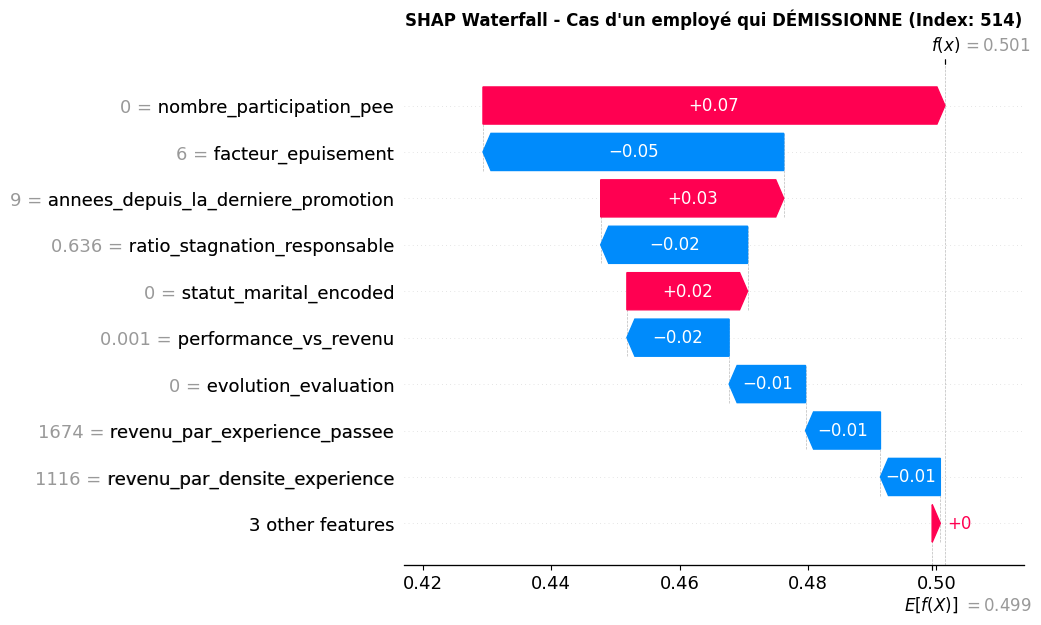

--------------------------------------------------


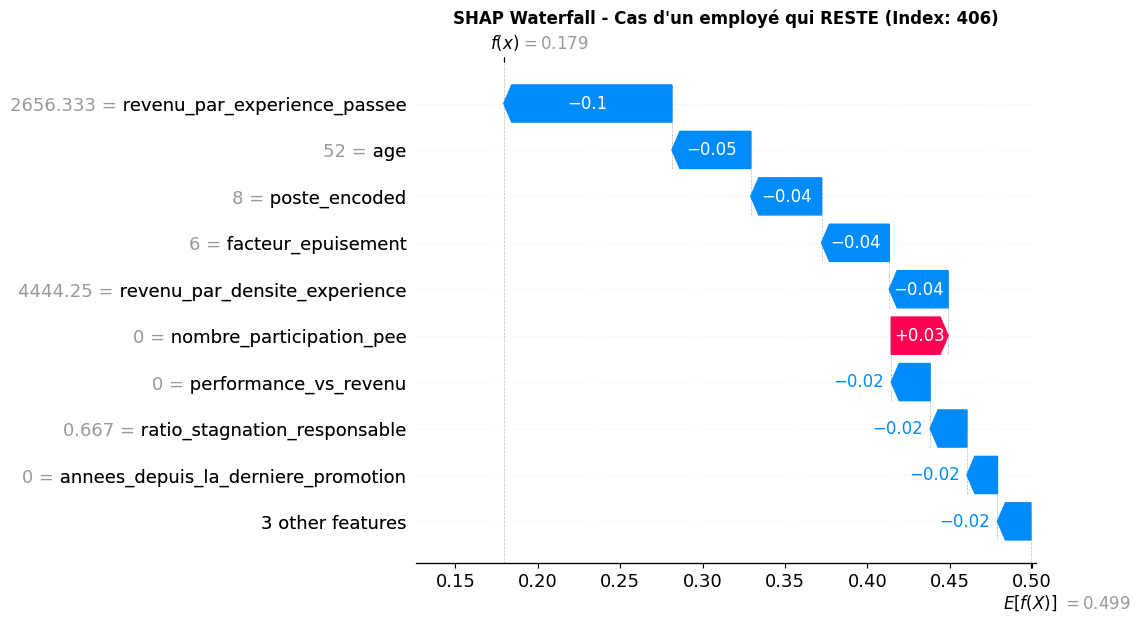

In [16]:
# 1. On cherche l'index d'un employé qui a RÉELLEMENT démissionné (Classe 1)
index_depart = y_test[y_test == 1].index[5]
position_depart = X_test.index.get_loc(index_depart)

# 2. On cherche l'index d'un employé qui est RÉELLEMENT resté (Classe 0)
index_reste = y_test[y_test == 0].index[5]
position_reste = X_test.index.get_loc(index_reste)

# 3. Tracé pour l'employé qui DÉMISSIONNE
plt.figure(figsize=(8, 5))
plt.title(f"SHAP Waterfall - Cas d'un employé qui DÉMISSIONNE (Index: {index_depart})", fontweight='bold')
shap.plots.waterfall(shap_values_depart[position_depart])
plt.show()

print("-" * 50)

# 4. Tracé pour l'employé qui RESTE
plt.figure(figsize=(8, 5))
plt.title(f"SHAP Waterfall - Cas d'un employé qui RESTE (Index: {index_reste})", fontweight='bold')
shap.plots.waterfall(shap_values_depart[position_reste])
plt.show()

`Observation:`
- Le graphique affiche une valeur attendue de base $E[f(X)] = 0.499$ (soit environ 50% de probabilité de départ par défaut). Ce taux est bien plus élevé que le taux de turnover réel de l'entreprise. Cet écart est tout à fait normal : il découle directement de l'utilisation du paramètre class_weight='balanced' lors de l'entraînement, qui force l'algorithme à accorder un poids équivalent aux départs et aux maintiens pour mieux apprendre à les distinguer.
- La cohérence des prédictions individuelles $f(x)$ et les limites du modèle :
Les résultats individuels $f(x)$ analysés ici sont parfaitement cohérents avec la réalité du terrain : le collaborateur qui a démissionné obtient un score de 0.501 (ce qui dépasse notre seuil de décision optimal de 0.429 et déclenche l'alerte RH), tandis que le collaborateur resté obtient un score de sécurité de 0.179. Néanmoins, le modèle n'étant pas infaillible, il est tout à fait possible de rencontrer des cas contradictoires (fausses alertes ou départs manqués). Cela reflète la marge d'erreur inhérente aux métriques globales de notre modèle.
- L'importance du contexte individuel. Sur le profil étudié, la variable nombre_participation_pee a eu un impact majeur pour retenir ou pousser l'employé vers la sortie. Cependant, l'interprétation locale SHAP nous rappelle qu'une variable n'agit jamais seule. Même si un paramètre est généralement protecteur (comme le fait d'avoir un grand nombre de participations PEE), la situation unique d'un individu peut faire qu'un effet inverse se produise, simplement parce que d'autres signaux négatifs cumulés ont pesé beaucoup plus lourd dans la balance finale.